In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

import numpy as np

warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report

import lightgbm as lgb
import xgboost as xgb

#Use SHAP to analyze the weight of the features
import shap


In [2]:
TRAIN_DATA_PATH = "../datasets/raw/application_train.csv"
BERAU_DATA_PATH = "../datasets/raw/bureau.csv"
IMAGES_PATH = "../images/"
OUTPUT_PATH = "../datasets/preprocess/"


BERAU__BALANCE_DATA_PATH = "../datasets/raw/bureau_balance.csv"
PREVIOUS_APPLICATION_DATA_PATH = "../datasets/raw/previous_application.csv"

INSTALLED__PAYMENTS_DATA_PATH = "../datasets/raw/installments_payments.csv"

In [3]:
# Load the main table (application_train)
app_train = pd.read_csv(TRAIN_DATA_PATH)

# Load bureau and do the aggregation
bureau = pd.read_csv(BERAU_DATA_PATH)

berau_balance = pd.read_csv(BERAU__BALANCE_DATA_PATH)

previous_app = pd.read_csv(PREVIOUS_APPLICATION_DATA_PATH)

installments = pd.read_csv(INSTALLED__PAYMENTS_DATA_PATH)

In [4]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'SK_ID_BUREAU': 'count',
    'DAYS_CREDIT': ['mean', 'max', 'min'],
    'AMT_CREDIT_SUM': ['mean', 'max', 'sum'],
    'AMT_CREDIT_SUM_DEBT': ['mean', 'sum'],
    'CREDIT_DAY_OVERDUE': ['mean', 'max'],
})
bureau_agg.columns = ['_'.join(col).upper() for col in bureau_agg.columns]
bureau_agg = bureau_agg.reset_index()

In [5]:
bureau_agg.head()   

,SK_ID_CURR,SK_ID_BUREAU_COUNT,DAYS_CREDIT_MEAN,DAYS_CREDIT_MAX,DAYS_CREDIT_MIN,AMT_CREDIT_SUM_MEAN,AMT_CREDIT_SUM_MAX,AMT_CREDIT_SUM_SUM,AMT_CREDIT_SUM_DEBT_MEAN,AMT_CREDIT_SUM_DEBT_SUM,CREDIT_DAY_OVERDUE_MEAN,CREDIT_DAY_OVERDUE_MAX
0,100001,7,-735.000000,-49,-1572,207623.571429,378000.0,1453365.000,85240.928571,596686.5,0.0,0
1,100002,8,-874.000000,-103,-1437,108131.945625,450000.0,865055.565,49156.200000,245781.0,0.0,0
2,100003,4,-1400.750000,-606,-2586,254350.125000,810000.0,1017400.500,0.000000,0.0,0.0,0
3,100004,2,-867.000000,-408,-1326,94518.900000,94537.8,189037.800,0.000000,0.0,0.0,0
4,100005,3,-190.666667,-62,-373,219042.000000,568800.0,657126.000,189469.500000,568408.5,0.0,0


In [6]:
bureau_agg.shape

(305811, 12)

In [7]:
#Apply merge with app train daatset like the left table
app_train = app_train.merge(bureau_agg, on='SK_ID_CURR', how='left')

In [8]:
display(app_train.head())

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,DAYS_CREDIT_MEAN,DAYS_CREDIT_MAX,DAYS_CREDIT_MIN,AMT_CREDIT_SUM_MEAN,AMT_CREDIT_SUM_MAX,AMT_CREDIT_SUM_SUM,AMT_CREDIT_SUM_DEBT_MEAN,AMT_CREDIT_SUM_DEBT_SUM,CREDIT_DAY_OVERDUE_MEAN,CREDIT_DAY_OVERDUE_MAX
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,-874.00,-103.0,-1437.0,108131.945625,450000.0,865055.565,49156.2,245781.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,-1400.75,-606.0,-2586.0,254350.125000,810000.0,1017400.500,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,-867.00,-408.0,-1326.0,94518.900000,94537.8,189037.800,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,-1149.00,-1149.0,-1149.0,146250.000000,146250.0,146250.000,0.0,0.0,0.0,0.0


In [9]:
print(app_train.shape)

(307511, 133)


In [10]:
app_train[['SK_ID_BUREAU_COUNT', 'DAYS_CREDIT_MEAN']].head()

,SK_ID_BUREAU_COUNT,DAYS_CREDIT_MEAN
0,8.0,-874.00
1,4.0,-1400.75
2,2.0,-867.00
3,NaN,NaN
4,1.0,-1149.00


In [11]:
app_train['SK_ID_BUREAU_COUNT'].isna().sum()

np.int64(44020)

In [12]:
app_train.to_csv(f"{OUTPUT_PATH}application_train_merged.csv", index=False)

In [13]:
display(berau_balance.head())

berau_balance['STATUS'].unique()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


array(['C', '0', 'X', '1', '2', '3', '5', '4'], dtype=object)

In [14]:
berau_balance['IS_OVERDUE'] = berau_balance['STATUS'].isin(['1', '2', '3', '4', '5'])

In [15]:
status_severity = {
    'C': 0,
    '0': 0,
    'X': 0,  
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    '5': 5,
}

berau_balance['STATUS_SEVERITY'] = berau_balance['STATUS'].map(status_severity)

In [16]:
berau_balance.head(5)

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS,IS_OVERDUE,STATUS_SEVERITY
0,5715448,0,C,False,0
1,5715448,-1,C,False,0
2,5715448,-2,C,False,0
3,5715448,-3,C,False,0
4,5715448,-4,C,False,0


In [17]:
berau_balance_agg = berau_balance.groupby('SK_ID_BUREAU').agg({
    'MONTHS_BALANCE':'count',
    'IS_OVERDUE':'sum',
    'STATUS_SEVERITY':'max'
})

berau_balance_agg = berau_balance_agg.rename(columns={
    'MONTHS_BALANCE': 'MONTHS_BALANCE_COUNT',
    'IS_OVERDUE': 'IS_OVERDUE_SUM',
    'STATUS_SEVERITY': 'STATUS_SEVERITY_MAX'
})

# NO necesitas la línea de '_'.join aquí, bórrala

berau_balance_agg = berau_balance_agg.reset_index()

display(berau_balance_agg.head(5))

,SK_ID_BUREAU,MONTHS_BALANCE_COUNT,IS_OVERDUE_SUM,STATUS_SEVERITY_MAX
0,5001709,97,0,0
1,5001710,83,0,0
2,5001711,4,0,0
3,5001712,19,0,0
4,5001713,22,0,0


In [18]:
bureau = bureau.merge(berau_balance_agg,on='SK_ID_BUREAU',how='left')

In [19]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,MONTHS_BALANCE_COUNT,IS_OVERDUE_SUM,STATUS_SEVERITY_MAX
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN,NaN,NaN,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN,NaN,NaN,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN,NaN,NaN,NaN


In [20]:
#check teh values NaN 
bureau['MONTHS_BALANCE_COUNT'].isna().sum() / len(bureau) * 100

np.float64(54.885727802156566)

In [21]:
berau_agg = bureau.groupby('SK_ID_CURR').agg({
    'SK_ID_BUREAU': 'count',                       # cuántos créditos previos tiene el cliente
    'DAYS_CREDIT': ['mean', 'max', 'min'],
    'AMT_CREDIT_SUM': ['mean', 'max', 'sum'],
    'AMT_CREDIT_SUM_DEBT': ['mean', 'sum'],
    'CREDIT_DAY_OVERDUE': ['mean', 'max'],
    'MONTHS_BALANCE_COUNT': ['mean', 'sum'],        # NUEVO: historial mensual promedio/total
    'IS_OVERDUE_SUM': ['mean', 'sum', 'max'],       # NUEVO: meses en atraso, promedio/total/peor caso
    'STATUS_SEVERITY_MAX': 'max',                   # NUEVO: peor nivel de atraso alcanzado en cualquier crédito
})

# Flatten the MultiIndex columns (same technique as before)
berau_agg.columns = ['_'.join(col).upper() for col in berau_agg.columns]
berau_agg = berau_agg.reset_index()

display(berau_agg.head())

,SK_ID_CURR,SK_ID_BUREAU_COUNT,DAYS_CREDIT_MEAN,DAYS_CREDIT_MAX,DAYS_CREDIT_MIN,AMT_CREDIT_SUM_MEAN,AMT_CREDIT_SUM_MAX,AMT_CREDIT_SUM_SUM,AMT_CREDIT_SUM_DEBT_MEAN,AMT_CREDIT_SUM_DEBT_SUM,CREDIT_DAY_OVERDUE_MEAN,CREDIT_DAY_OVERDUE_MAX,MONTHS_BALANCE_COUNT_MEAN,MONTHS_BALANCE_COUNT_SUM,IS_OVERDUE_SUM_MEAN,IS_OVERDUE_SUM_SUM,IS_OVERDUE_SUM_MAX,STATUS_SEVERITY_MAX_MAX
0,100001,7,-735.000000,-49,-1572,207623.571429,378000.0,1453365.000,85240.928571,596686.5,0.0,0,24.571429,172.0,0.142857,1.0,1.0,1.0
1,100002,8,-874.000000,-103,-1437,108131.945625,450000.0,865055.565,49156.200000,245781.0,0.0,0,13.750000,110.0,3.375000,27.0,6.0,1.0
2,100003,4,-1400.750000,-606,-2586,254350.125000,810000.0,1017400.500,0.000000,0.0,0.0,0,NaN,0.0,NaN,0.0,NaN,NaN
3,100004,2,-867.000000,-408,-1326,94518.900000,94537.8,189037.800,0.000000,0.0,0.0,0,NaN,0.0,NaN,0.0,NaN,NaN
4,100005,3,-190.666667,-62,-373,219042.000000,568800.0,657126.000,189469.500000,568408.5,0.0,0,7.000000,21.0,0.000000,0.0,0.0,0.0


In [22]:
#Merge Train with Berau 
app_train = app_train.merge(berau_agg, on='SK_ID_CURR', how='left')


display(app_train.head())

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_CREDIT_SUM_DEBT_MEAN_y,AMT_CREDIT_SUM_DEBT_SUM_y,CREDIT_DAY_OVERDUE_MEAN_y,CREDIT_DAY_OVERDUE_MAX_y,MONTHS_BALANCE_COUNT_MEAN,MONTHS_BALANCE_COUNT_SUM,IS_OVERDUE_SUM_MEAN,IS_OVERDUE_SUM_SUM,IS_OVERDUE_SUM_MAX,STATUS_SEVERITY_MAX_MAX
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,49156.2,245781.0,0.0,0.0,13.75,110.0,3.375,27.0,6.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,NaN,NaN
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,NaN,NaN
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,NaN,NaN


In [23]:
#Previous Data
previous_app_agg = previous_app.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV': 'count',                        # cuántas solicitudes previas tiene
    'AMT_CREDIT': ['mean', 'max', 'sum'],          # monto de crédito solicitado
    'AMT_ANNUITY': ['mean', 'max'],                # pago mensual (anualidad)
    'CNT_PAYMENT': ['mean', 'max'],                # plazo de pago en meses
    'DAYS_DECISION': ['mean', 'min'],               # qué tan reciente/antigua es la última decisión
})

previous_app_agg.columns = ['_'.join(col).upper() for col in previous_app_agg.columns]
previous_app_agg = previous_app_agg.reset_index()

previous_app_agg.head()

,SK_ID_CURR,SK_ID_PREV_COUNT,AMT_CREDIT_MEAN,AMT_CREDIT_MAX,AMT_CREDIT_SUM,AMT_ANNUITY_MEAN,AMT_ANNUITY_MAX,CNT_PAYMENT_MEAN,CNT_PAYMENT_MAX,DAYS_DECISION_MEAN,DAYS_DECISION_MIN
0,100001,1,23787.00,23787.0,23787.0,3951.000,3951.000,8.0,8.0,-1740.0,-1740
1,100002,1,179055.00,179055.0,179055.0,9251.775,9251.775,24.0,24.0,-606.0,-606
2,100003,3,484191.00,1035882.0,1452573.0,56553.990,98356.995,10.0,12.0,-1305.0,-2341
3,100004,1,20106.00,20106.0,20106.0,5357.250,5357.250,4.0,4.0,-815.0,-815
4,100005,2,20076.75,40153.5,40153.5,4813.200,4813.200,12.0,12.0,-536.0,-757


In [24]:
app_train = app_train.merge(previous_app_agg,on='SK_ID_CURR',how='left')

display(app_train.head())

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,SK_ID_PREV_COUNT,AMT_CREDIT_MEAN,AMT_CREDIT_MAX,AMT_CREDIT_SUM,AMT_ANNUITY_MEAN,AMT_ANNUITY_MAX,CNT_PAYMENT_MEAN,CNT_PAYMENT_MAX,DAYS_DECISION_MEAN,DAYS_DECISION_MIN
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,1.0,179055.00,179055.0,179055.0,9251.775,9251.775,24.000000,24.0,-606.000000,-606.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,3.0,484191.00,1035882.0,1452573.0,56553.990,98356.995,10.000000,12.0,-1305.000000,-2341.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,1.0,20106.00,20106.0,20106.0,5357.250,5357.250,4.000000,4.0,-815.000000,-815.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,9.0,291695.50,906615.0,2625259.5,23651.175,39954.510,23.000000,48.0,-272.444444,-617.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,6.0,166638.75,284400.0,999832.5,12278.805,22678.785,20.666667,48.0,-1222.833333,-2357.0


In [25]:
#installments data section
display(installments.head())

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [26]:
installments['DAYS_LATE'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']
installments['AMT_SHORTFALL'] = installments['AMT_INSTALMENT'] - installments['AMT_PAYMENT']

installments.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,DAYS_LATE,AMT_SHORTFALL
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360,-7.0,0.000
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525,0.0,0.000
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000,0.0,0.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130,-8.0,0.000
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585,17.0,4.455


In [27]:
installments_agg = installments.groupby('SK_ID_PREV').agg({
    'AMT_INSTALMENT':'count',
    'DAYS_LATE': ['mean','max'],
    'AMT_SHORTFALL':['mean','max']
})


installments_agg.columns = ['_'.join(col).upper() for col in installments_agg.columns]
installments_agg = installments_agg.reset_index()

installments_agg.head()

,SK_ID_PREV,AMT_INSTALMENT_COUNT,DAYS_LATE_MEAN,DAYS_LATE_MAX,AMT_SHORTFALL_MEAN,AMT_SHORTFALL_MAX
0,1000001,2,-16.000000,-6.0,0.000000,0.000
1,1000002,4,-19.750000,-5.0,0.000000,0.000
2,1000003,3,-15.333333,-14.0,0.000000,0.000
3,1000004,7,-26.714286,-10.0,0.000000,0.000
4,1000005,11,-8.454545,3.0,1337.600455,14710.815


In [28]:
#merge previous app data with installments data
previous_app = previous_app.merge(installments_agg, on='SK_ID_PREV', how='left')

previous_app.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL,AMT_INSTALMENT_COUNT,DAYS_LATE_MEAN,DAYS_LATE_MAX,AMT_SHORTFALL_MEAN,AMT_SHORTFALL_MAX
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,-42.0,300.0,-42.0,-37.0,0.0,1.0,0.000000,0.0,0.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,-134.0,916.0,365243.0,365243.0,1.0,5.0,-9.200000,-7.0,0.0,0.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,-271.0,59.0,365243.0,365243.0,1.0,9.0,-8.222222,1.0,0.0,0.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,-482.0,-152.0,-182.0,-177.0,1.0,11.0,-7.090909,0.0,0.0,0.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
previous_app_agg = previous_app.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV': 'count',
    'AMT_CREDIT': ['mean', 'max', 'sum'],
    'AMT_ANNUITY': ['mean', 'max'],
    'CNT_PAYMENT': ['mean', 'max'],
    'DAYS_DECISION': ['mean', 'min'],
    'DAYS_LATE_MEAN': 'mean',           # promedio del atraso promedio de cada solicitud
    'DAYS_LATE_MAX': 'max',             # el peor atraso de todas sus solicitudes
    'AMT_SHORTFALL_MEAN': 'mean',
    'AMT_SHORTFALL_MAX': 'max',
})

previous_app_agg.columns = ['_'.join(col).upper() for col in previous_app_agg.columns]
previous_app_agg = previous_app_agg.reset_index()

display(previous_app_agg.head())

,SK_ID_CURR,SK_ID_PREV_COUNT,AMT_CREDIT_MEAN,AMT_CREDIT_MAX,AMT_CREDIT_SUM,AMT_ANNUITY_MEAN,AMT_ANNUITY_MAX,CNT_PAYMENT_MEAN,CNT_PAYMENT_MAX,DAYS_DECISION_MEAN,DAYS_DECISION_MIN,DAYS_LATE_MEAN_MEAN,DAYS_LATE_MAX_MAX,AMT_SHORTFALL_MEAN_MEAN,AMT_SHORTFALL_MAX_MAX
0,100001,1,23787.00,23787.0,23787.0,3951.000,3951.000,8.0,8.0,-1740.0,-1740,-15.500000,-6.0,0.0,0.0
1,100002,1,179055.00,179055.0,179055.0,9251.775,9251.775,24.0,24.0,-606.0,-606,-20.421053,-12.0,0.0,0.0
2,100003,3,484191.00,1035882.0,1452573.0,56553.990,98356.995,10.0,12.0,-1305.0,-2341,-7.448413,-1.0,0.0,0.0
3,100004,1,20106.00,20106.0,20106.0,5357.250,5357.250,4.0,4.0,-815.0,-815,-7.666667,-3.0,0.0,0.0
4,100005,2,20076.75,40153.5,40153.5,4813.200,4813.200,12.0,12.0,-536.0,-757,-23.555556,1.0,0.0,0.0


In [30]:
# Reload fresh application_train
app_train = pd.read_csv(TRAIN_DATA_PATH)

# Merge bureau (ya con bureau_balance incluido)
app_train = app_train.merge(bureau_agg, on='SK_ID_CURR', how='left')

# Merge previous_application (ya con installments incluido)
app_train = app_train.merge(previous_app_agg, on='SK_ID_CURR', how='left')

print(app_train.shape)

(307511, 147)


In [31]:
# ¿Cuántas columnas nuevas quedaron con muchos nulos por clientes sin match?
(app_train.isna().sum() * 100 / len(app_train)).sort_values(ascending=False).head(20)

COMMONAREA_MEDI             69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_AVG              69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
LANDAREA_MEDI               59.376738
dtype: float64

In [32]:
new_cols = [col for col in app_train.columns if col in ['SK_ID_BUREAU_COUNT', 'AMT_CREDIT_MEAN', 'DAYS_CREDIT_MEAN']]
(app_train[new_cols].isna().sum() * 100 / len(app_train))

SK_ID_BUREAU_COUNT    14.314935
DAYS_CREDIT_MEAN      14.314935
AMT_CREDIT_MEAN        5.350703
dtype: float64

In [33]:
# Drop Columns with a threshold 60%
null_pct = app_train.isna().sum() * 100 / len(app_train)
cols_to_drop = null_pct[null_pct > 60].index.to_list()

print(f"Columns to drop: {len(cols_to_drop)}")
print(cols_to_drop)

app_train = app_train.drop(columns=cols_to_drop)
print(app_train.shape)

Columns to drop: 17
['OWN_CAR_AGE', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'FLOORSMIN_AVG', 'LIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_AVG', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'FLOORSMIN_MODE', 'LIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MODE', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'FLOORSMIN_MEDI', 'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE']
(307511, 130)


In [34]:
# 1. Create the flag BEFORE tocuhing the original value
app_train['DAYS_EMPLOYED_ANOMALY'] = (app_train['DAYS_EMPLOYED'] == 365243)

# 2. Replace the placeholder by NaN
app_train['DAYS_EMPLOYED'] = app_train['DAYS_EMPLOYED'].replace(365243, np.nan)

In [35]:
print(app_train['DAYS_EMPLOYED'].describe())
print("\n")
print(app_train['DAYS_EMPLOYED_ANOMALY'].value_counts())

count    252137.000000
mean      -2384.169325
std        2338.360162
min      -17912.000000
25%       -3175.000000
50%       -1648.000000
75%        -767.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64


DAYS_EMPLOYED_ANOMALY
False    252137
True      55374
Name: count, dtype: int64


In [36]:
new_feature_cols = [col for col in app_train.columns if col not in pd.read_csv(TRAIN_DATA_PATH, nrows=0).columns]
print(new_feature_cols)

['SK_ID_BUREAU_COUNT', 'DAYS_CREDIT_MEAN', 'DAYS_CREDIT_MAX', 'DAYS_CREDIT_MIN', 'AMT_CREDIT_SUM_MEAN', 'AMT_CREDIT_SUM_MAX', 'AMT_CREDIT_SUM_SUM', 'AMT_CREDIT_SUM_DEBT_MEAN', 'AMT_CREDIT_SUM_DEBT_SUM', 'CREDIT_DAY_OVERDUE_MEAN', 'CREDIT_DAY_OVERDUE_MAX', 'SK_ID_PREV_COUNT', 'AMT_CREDIT_MEAN', 'AMT_CREDIT_MAX', 'AMT_CREDIT_SUM', 'AMT_ANNUITY_MEAN', 'AMT_ANNUITY_MAX', 'CNT_PAYMENT_MEAN', 'CNT_PAYMENT_MAX', 'DAYS_DECISION_MEAN', 'DAYS_DECISION_MIN', 'DAYS_LATE_MEAN_MEAN', 'DAYS_LATE_MAX_MAX', 'AMT_SHORTFALL_MEAN_MEAN', 'AMT_SHORTFALL_MAX_MAX', 'DAYS_EMPLOYED_ANOMALY']


In [37]:
#FILL NaN values
columns_to_fill = ['SK_ID_BUREAU_COUNT', 'SK_ID_PREV_COUNT', 'AMT_CREDIT_SUM_SUM', 'AMT_CREDIT_SUM_DEBT_SUM']

for col in columns_to_fill:
    app_train[col] = app_train[col].fillna(0)

In [38]:
print(app_train.shape)
print(app_train[columns_to_fill].isna().sum())

(307511, 131)
SK_ID_BUREAU_COUNT         0
SK_ID_PREV_COUNT           0
AMT_CREDIT_SUM_SUM         0
AMT_CREDIT_SUM_DEBT_SUM    0
dtype: int64


In [39]:
#check the categorical features to apply one hot encoding
categorical_cols = []
i = 1
for col in app_train.columns:
    if app_train[col].dtype == "object":
        categorical_cols.append(col)
        print(f"{i}. {col} -> unique values: {app_train[col].nunique()}")
        i += 1

print(f"\nTotal categorical columns: {len(categorical_cols)}")

1. NAME_CONTRACT_TYPE -> unique values: 2
2. CODE_GENDER -> unique values: 3
3. FLAG_OWN_CAR -> unique values: 2
4. FLAG_OWN_REALTY -> unique values: 2
5. NAME_TYPE_SUITE -> unique values: 7
6. NAME_INCOME_TYPE -> unique values: 8
7. NAME_EDUCATION_TYPE -> unique values: 5
8. NAME_FAMILY_STATUS -> unique values: 6
9. NAME_HOUSING_TYPE -> unique values: 6
10. OCCUPATION_TYPE -> unique values: 18
11. WEEKDAY_APPR_PROCESS_START -> unique values: 7
12. ORGANIZATION_TYPE -> unique values: 58
13. HOUSETYPE_MODE -> unique values: 3
14. WALLSMATERIAL_MODE -> unique values: 7
15. EMERGENCYSTATE_MODE -> unique values: 2

Total categorical columns: 15


In [40]:
cols_to_ohe = []
for col in app_train.columns:
    if app_train[col].dtype == "object" and app_train[col].nunique() <= 8:
        cols_to_ohe.append(col)

print(len(cols_to_ohe))
print(cols_to_ohe)   


13
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [41]:
app_train = pd.get_dummies(app_train,columns=cols_to_ohe,drop_first=True)

print(app_train.shape)

(307511, 165)


In [42]:
'NAME_CONTRACT_TYPE' in app_train.columns

False

In [43]:
#Frequency Encoding to Fetaures with high cardinality in object features
app_train['ORGANIZATION_TYPE'].value_counts(normalize=True)

ORGANIZATION_TYPE
Business Entity Type 3    0.221104
XNA                       0.180072
Self-employed             0.124913
Other                     0.054252
Medicine                  0.036399
Business Entity Type 2    0.034317
Government                0.033833
School                    0.028919
Trade: type 7             0.025466
Kindergarten              0.022373
Construction              0.021856
Business Entity Type 1    0.019459
Transport: type 4         0.017554
Trade: type 3             0.011356
Industry: type 9          0.010952
Industry: type 3          0.010660
Security                  0.010559
Housing                   0.009619
Industry: type 11         0.008793
Military                  0.008566
Bank                      0.008153
Agriculture               0.007980
Police                    0.007613
Transport: type 2         0.007167
Postal                    0.007014
Security Ministries       0.006419
Trade: type 2             0.006179
Restaurant                0.005889
Se

In [44]:
app_train['OCCUPATION_TYPE'].value_counts(normalize=True)

OCCUPATION_TYPE
Laborers                 0.261396
Sales staff              0.152056
Core staff               0.130589
Managers                 0.101227
Drivers                  0.088116
High skill tech staff    0.053903
Accountants              0.046481
Medicine staff           0.040437
Security staff           0.031835
Cooking staff            0.028164
Cleaning staff           0.022040
Private service staff    0.012562
Low-skill Laborers       0.009914
Waiters/barmen staff     0.006385
Secretaries              0.006181
Realty agents            0.003557
HR staff                 0.002667
IT staff                 0.002491
Name: proportion, dtype: float64

In [45]:
occupation_freq = app_train['OCCUPATION_TYPE'].value_counts(normalize=True)
app_train['OCCUPATION_TYPE_FREQ'] = app_train['OCCUPATION_TYPE'].map(occupation_freq)

organization_freq = app_train['ORGANIZATION_TYPE'].value_counts(normalize=True)
app_train['ORGANIZATION_TYPE_FREQ'] = app_train['ORGANIZATION_TYPE'].map(organization_freq)

In [46]:
#delete features with high cardinality once we have the frequency encoding for that features
app_train = app_train.drop(columns=['OCCUPATION_TYPE', 'ORGANIZATION_TYPE'])

In [47]:
print(app_train[['OCCUPATION_TYPE_FREQ', 'ORGANIZATION_TYPE_FREQ']].head())
print(app_train.shape)

   OCCUPATION_TYPE_FREQ  ORGANIZATION_TYPE_FREQ
0              0.261396                0.221104
1              0.130589                0.028919
2              0.261396                0.033833
3              0.261396                0.221104
4              0.130589                0.000276
(307511, 165)


In [48]:
#check there is no exist more categorical features
app_train.dtypes.value_counts()

float64    77
bool       48
int64      40
Name: count, dtype: int64

In [49]:
app_train.to_csv(f"{OUTPUT_PATH}application_train_final.csv", index=False)

In [50]:
X = app_train.drop(labels=["SK_ID_CURR",'TARGET'],axis=1)
y = app_train["TARGET"]


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


In [51]:
cols_with_null_values = []

for col in X_train.columns:
    if X_train[col].isna().sum() > 0:
        cols_with_null_values.append(col)

print(len(cols_with_null_values))
print(cols_with_null_values)

68
['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_EMPLOYED', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'LANDAREA_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'LANDAREA_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'LANDAREA_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAREA_MEDI', 'TOTALAREA_MODE', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'D

In [52]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)

X_test_imputed = imputer.transform(X_test)

In [53]:
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

In [54]:
#check that there are no longer any null values
print(type(X_train_imputed))
print(X_train_imputed.isna().sum().sum())  # debería dar 0
print(X_test_imputed.isna().sum().sum())   # debería dar 0

<class 'pandas.core.frame.DataFrame'>
0
0


In [55]:
#setup mlflow for experimenst tracking
import mlflow
import mlflow.sklearn


mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("credit_risk_baseline")

2026/07/30 13:23:18 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/30 13:23:18 INFO mlflow.store.db.utils: Updating database tables
2026/07/30 13:23:20 INFO mlflow.tracking.fluent: Experiment with name 'credit_risk_baseline' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///c:/Users/sgfar/anaconda_projects/PythonJupyterProject/CreditRisk/notebooks/mlruns/1', creation_time=1785439400169, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1785439400169, lifecycle_stage='active', name='credit_risk_baseline', tags={}, trace_location=None, workspace='default'>

In [56]:
MAX_ITER = 1000


#Logistic Regression Model
with mlflow.start_run(run_name="logistic_regression_baseline"):

    log_reg = LogisticRegression(max_iter=MAX_ITER, random_state=42)

    #Apply Cross validuation to get PC-AUC
    skf  = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

    cv_scores = cross_val_score(log_reg,X_train_imputed,y_train,cv=skf,scoring='average_precision')

    for i,score in enumerate(cv_scores):
        mlflow.log_metric(f"pr_auc_fold_{i}",score)
        print(f"{i}. {score}")

    #track log metrics for cv score
    mlflow.log_metrics({
        "pr_auc_cv_mean": cv_scores.mean(),
        "pr_auc_cv_std": cv_scores.std()
    })    

    #print(f"PR-AUC scores por fold: {cv_scores}")
    #print(f"PR-AUC mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


    log_reg.fit(X_train_imputed,y_train)
    y_pred_proba = log_reg.predict_proba(X_test_imputed)[:,1]

    roc_auc_test = roc_auc_score(y_test,y_pred_proba)
    pr_auc_test = average_precision_score(y_test,y_pred_proba)

    #track log metrics model
    mlflow.log_metrics({
        "roc_auc_test": roc_auc_test,
        "pr_auc_test": pr_auc_test
    })

    mlflow.log_params({
        "model_type":"LogisticRegression",
        "max_iter": MAX_ITER
    })

    mlflow.sklearn.log_model(log_reg,"model")

    print(f"CV PR-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"ROC AUC Test: {roc_auc_test}")
    print(f"Test PR-AUC: {pr_auc_test:.4f}")
    


0. 0.14387619277921104
1. 0.1378770903835903
2. 0.14317654683672984
3. 0.13783500048101566
4. 0.13604647109945012


2026/07/30 13:27:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


CV PR-AUC: 0.1398 (+/- 0.0032)
ROC AUC Test: 0.659603777078055
Test PR-AUC: 0.1381


In [57]:
import re

X_train.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X_train.columns]
X_test.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X_test.columns]

In [61]:
#LightGBM Model

with mlflow.start_run(run_name="light_gmb_baseline"):

    lightgbm = lgb.LGBMClassifier(n_estimators=1000,
                                  learning_rate=0.05,
                                  max_depth=5,
                                  class_weight='balanced',
                                  random_state=42)

    mlflow.log_params({
        "n_estimators": 1000,
        "learning_rate": 0.05,
        "max_depth":5,
        "class_weight":"balanced"

    })

    skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)


    cv_scores = cross_val_score(lightgbm,X_train,y_train,cv=skf,scoring="average_precision")

    for i,score in enumerate(cv_scores):
        mlflow.log_metric(f"pr_auc_fold_{i}",score)
        print(f"{i}. {score}")


    mlflow.log_metrics({
        "pr_auc_cv_mean": cv_scores.mean(),
        "pr_auc_cv_std": cv_scores.std()
    })

    lightgbm.fit(X_train,y_train)

    prediction_proba = lightgbm.predict_proba(X_test)[:, 1]

    roc_auc_test = roc_auc_score(y_test,prediction_proba)
    pr_auc_test = average_precision_score(y_test,prediction_proba)

    
    mlflow.log_metrics({
            "roc_auc_test": roc_auc_test,
            "pr_auc_test": pr_auc_test
    })
    
    mlflow.log_params({
            "model_type":"LGBMClassifier",
    })

    mlflow.sklearn.log_model(lightgbm,"model",skops_trusted_types=["collections.OrderedDict", "lightgbm.basic.Booster", "lightgbm.sklearn.LGBMClassifier"])

    print(f"CV PR-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"ROC AUC Test: {roc_auc_test}")
    print(f"Test PR-AUC: {pr_auc_test:.4f}")

   

[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.053649 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14522
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 153
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

2026/07/30 14:24:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


CV PR-AUC: 0.2560 (+/- 0.0054)
ROC AUC Test: 0.7741753311775943
Test PR-AUC: 0.2680


In [62]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

11.38710976837865


In [64]:
#XGBoost model
with mlflow.start_run(run_name="xgboost__baseline"):

    xgboost = xgb.XGBClassifier(n_estimators=1000,
                                learning_rate=0.05,
                                max_depth=5,
                                scale_pos_weight=scale_pos_weight,
                                eval_metric='aucpr',
                                random_state=42
                        )


    mlflow.log_params({
            "n_estimators": 1000,
            "learning_rate": 0.05,
            "max_depth":5,
            "scale_pos_weight":scale_pos_weight,
            "eval_metric": 'aucpr'    
    })



    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(xgboost, X_train, y_train, cv=skf, scoring="average_precision")
    
    for i, score in enumerate(cv_scores):
        mlflow.log_metric(f"pr_auc_fold_{i}", score)
        print(f"{i}. {score}")
    
    mlflow.log_metrics({
        "pr_auc_cv_mean": cv_scores.mean(),
        "pr_auc_cv_std": cv_scores.std()
    })
    
    xgboost.fit(X_train, y_train)
    
    prediction_proba = xgboost.predict_proba(X_test)[:, 1]
    
    roc_auc_test = roc_auc_score(y_test, prediction_proba)
    pr_auc_test = average_precision_score(y_test, prediction_proba)
    
    mlflow.log_metrics({
        "roc_auc_test": roc_auc_test,
        "pr_auc_test": pr_auc_test
    })
    
    mlflow.log_params({"model_type": "XGBClassifier"})
    mlflow.xgboost.log_model(xgboost, "model")
    
    print(f"CV PR-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"ROC AUC Test: {roc_auc_test}")
    print(f"Test PR-AUC: {pr_auc_test:.4f}")

0. 0.25204129490386007
1. 0.2515677666552069
2. 0.2619420730560176
3. 0.2600807140317764
4. 0.2522750086373096


2026/07/30 14:50:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


CV PR-AUC: 0.2556 (+/- 0.0045)
ROC AUC Test: 0.7729508465943838
Test PR-AUC: 0.2683


In [66]:
#use XGBoost for this case
explainer = shap.TreeExplainer(xgboost)

X_test_sample = X_test.sample(n=1000,random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print(X_test_sample.shape)


(1000, 163)


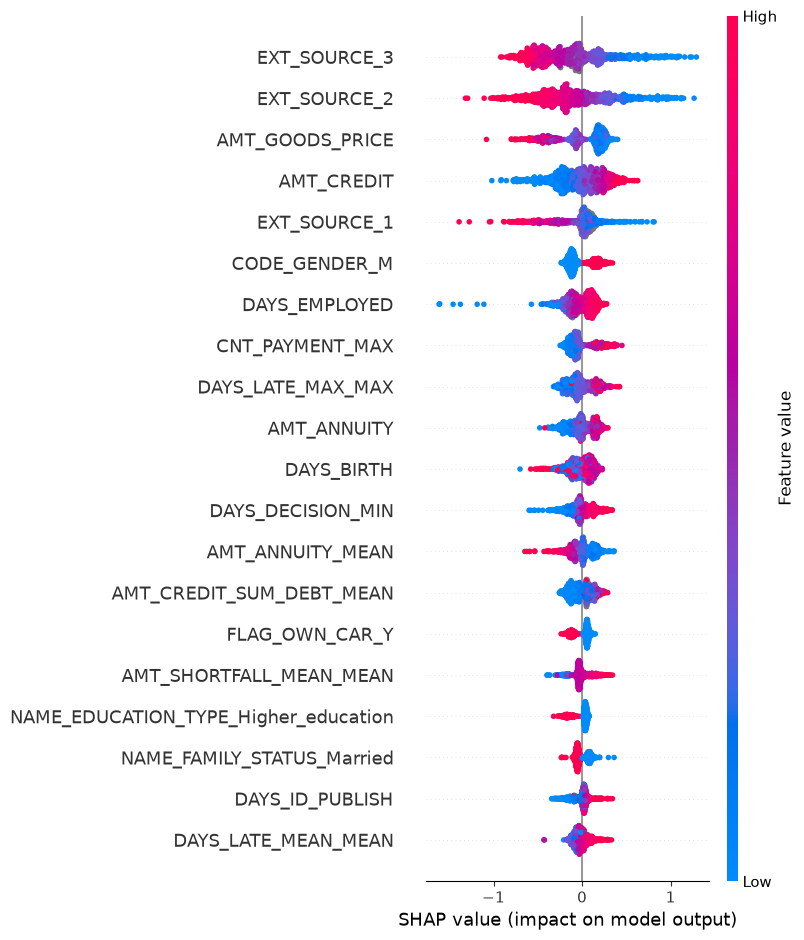

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test_sample)

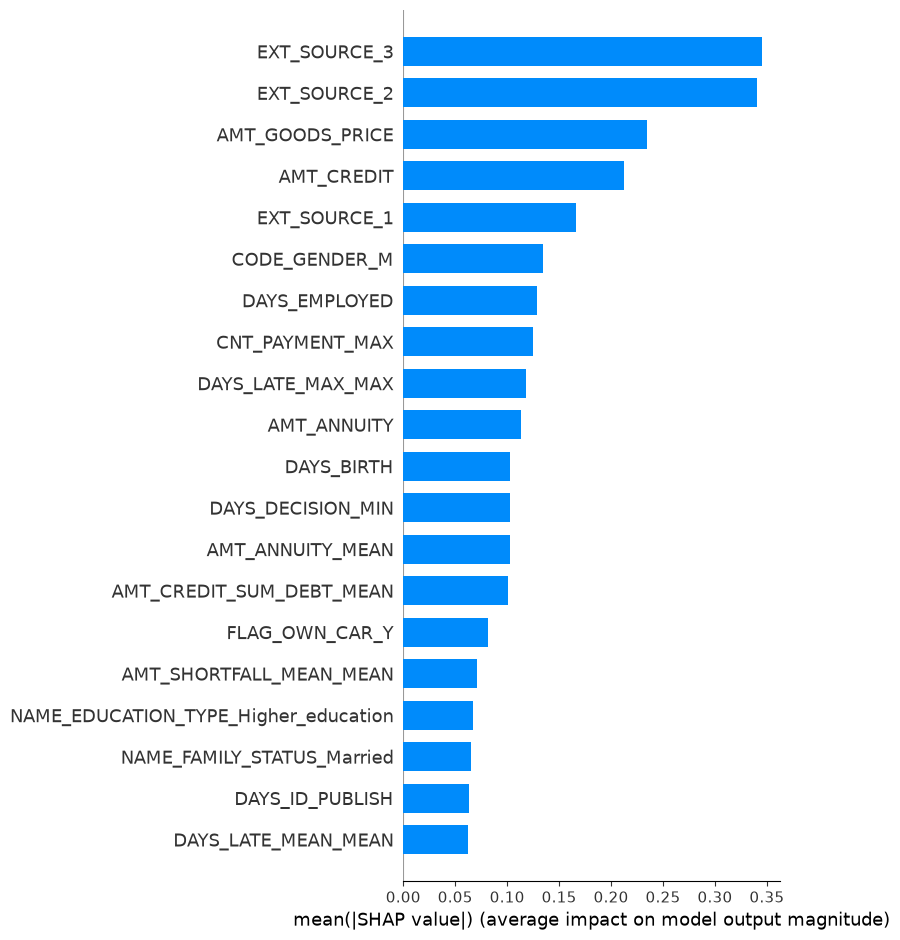

In [69]:
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")

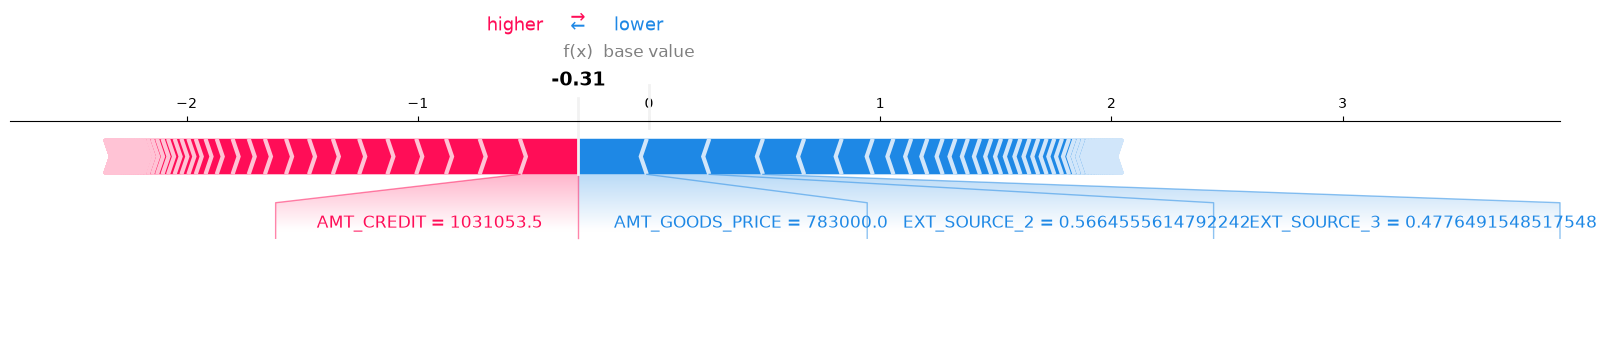

In [ ]:
# Choose a specific customer for the analysis
idx = 0

shap.force_plot(
    explainer.expected_value, 
    shap_values[idx], 
    X_test_sample.iloc[idx],
    matplotlib=True
)

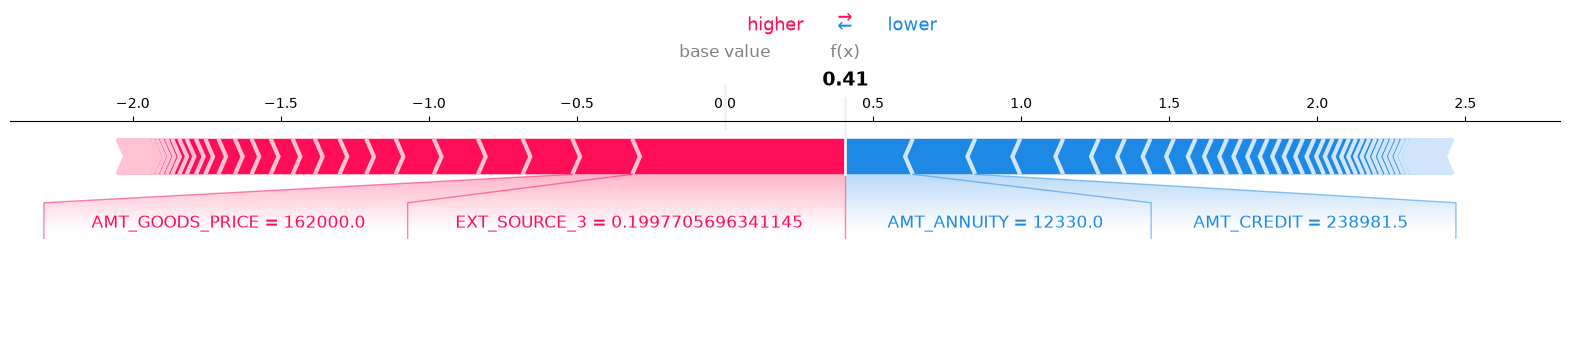

In [71]:
idx = 500

shap.force_plot(
    explainer.expected_value, 
    shap_values[idx], 
    X_test_sample.iloc[idx],
    matplotlib=True
)

In [ ]:
#Setup Optuma for Hyperparameters Tracking with XGBoost
print(X_train.shape)
print(y_train.shape)

(246008, 163)
(246008,)


In [74]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': scale_pos_weight,
        'eval_metric': 'aucpr',
        'random_state': 42
    }

    model = xgb.XGBClassifier(**params,verbose=-1)
    skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='average_precision')

    return scores.mean()


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print("Best Hyperparameters:", study.best_params)
print("Best PR-AUC (CV):", study.best_value)

[I 2026-07-30 16:49:25,166] A new study created in memory with name: no-name-08dee609-9732-447a-adbf-1db1726b959e
[I 2026-07-30 16:49:55,381] Trial 0 finished with value: 0.23933033062159423 and parameters: {'n_estimators': 136, 'learning_rate': 0.016911462753882982, 'max_depth': 9, 'subsample': 0.9849038885906047, 'colsample_bytree': 0.7322485524138655, 'min_child_weight': 7}. Best is trial 0 with value: 0.23933033062159423.
[I 2026-07-30 16:51:50,043] Trial 1 finished with value: 0.23158613859310462 and parameters: {'n_estimators': 763, 'learning_rate': 0.062373134873903974, 'max_depth': 10, 'subsample': 0.8519454116570448, 'colsample_bytree': 0.9054002802308687, 'min_child_weight': 9}. Best is trial 0 with value: 0.23933033062159423.
[I 2026-07-30 16:52:43,735] Trial 2 finished with value: 0.25816080617249426 and parameters: {'n_estimators': 635, 'learning_rate': 0.01599179651871247, 'max_depth': 6, 'subsample': 0.7674082442462673, 'colsample_bytree': 0.6308721516278801, 'min_child_

Best Hyperparameters: {'n_estimators': 523, 'learning_rate': 0.05008219525657953, 'max_depth': 5, 'subsample': 0.9143278850136876, 'colsample_bytree': 0.8310980248155739, 'min_child_weight': 8}
Best PR-AUC (CV): 0.2597730828545177


In [77]:
with mlflow.start_run(run_name="xgboost_optuna_tuned"):
    
    best_params = study.best_params
    best_params['scale_pos_weight'] = scale_pos_weight
    best_params['eval_metric'] = 'aucpr'
    best_params['random_state'] = 42
    
    final_model = xgb.XGBClassifier(**best_params)
    final_model.fit(X_train, y_train)
    
    y_pred_proba = final_model.predict_proba(X_test)[:, 1]
    
    roc_auc_test = roc_auc_score(y_test, y_pred_proba)
    pr_auc_test = average_precision_score(y_test, y_pred_proba)
    
    mlflow.log_params(best_params)
    mlflow.log_param("model_type", "XGBClassifier_Optuna")
    mlflow.log_metric("cv_pr_auc", study.best_value)
    mlflow.log_metric("roc_auc_test", roc_auc_test)
    mlflow.log_metric("pr_auc_test", pr_auc_test)
    
    mlflow.xgboost.log_model(
        final_model, 
        "model",
        #skops_trusted_types=["collections.OrderedDict"]
    )
    
    print(f"Test ROC-AUC: {roc_auc_test:.4f}")
    print(f"Test PR-AUC: {pr_auc_test:.4f}")

2026/07/30 17:14:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Test ROC-AUC: 0.7770
Test PR-AUC: 0.2730


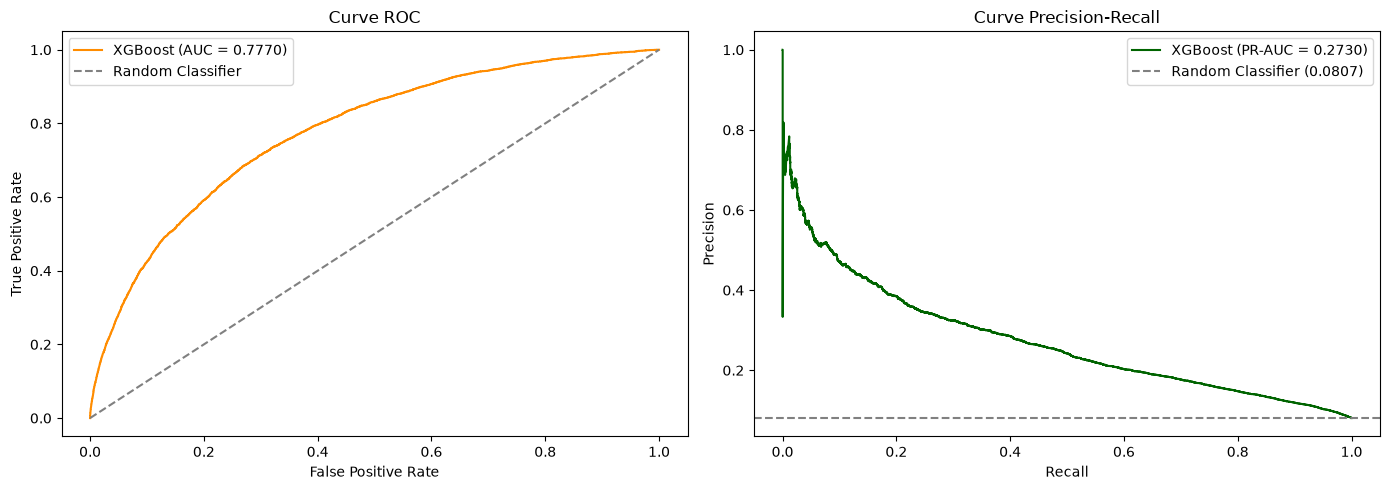

In [79]:
from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

# Necesitas las probabilidades predichas (ya las tienes como y_pred_proba)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Curva ROC ---
axes[0].plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_test:.4f})', color='darkorange')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curve ROC')
axes[0].legend()

# --- Gráfico 2: Curva Precision-Recall ---
baseline = y_test.mean()  # proporción de la clase positiva, línea base de referencia
axes[1].plot(recall, precision, label=f'XGBoost (PR-AUC = {pr_auc_test:.4f})', color='darkgreen')
axes[1].axhline(y=baseline, linestyle='--', color='gray', label=f'Random Classifier ({baseline:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curve Precision-Recall')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{IMAGES_PATH}roc_pr_curves.png", dpi=150)
plt.show()